# **Preparing Dependencies**

In [3]:
# If dependencies are missing, install with uv in terminal:
# uv add torch diffusers transformers accelerate safetensors

import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from IPython.display import display

# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [8]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
 )
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++",
    use_karras_sigmas=True,
 )
pipe = pipe.to(DEVICE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## **Generate Image**

  0%|          | 0/50 [00:00<?, ?it/s]

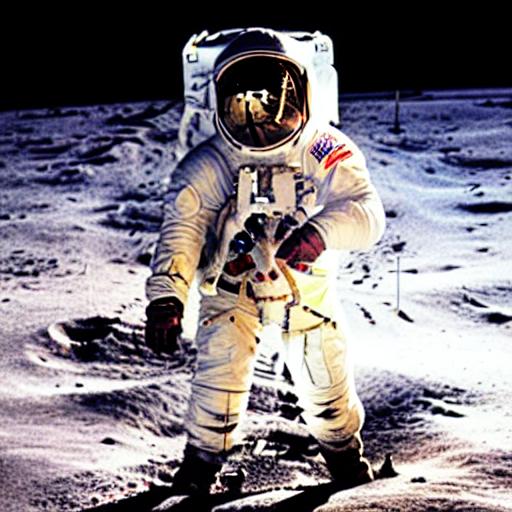

In [15]:
def generate_simple_image(
        prompt: str, 
        negative_prompt: str = "", 
        seed: int = 42,
        width: int = 512,
        height: int = 512,
        ):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        width=width,
        height=height,
    )
    return result.images[0]

TARGET_PROMPT = (
    "an astronaut with full white spacesuit, standing on a flat moon plain, with earth in the background, minimal detail, 2D digital art"
)

TARGET_NEGATIVE_PROMPT = (
    "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"
)

TARGET_SEED = 222

simple_image = generate_simple_image(
    prompt=TARGET_PROMPT,
    negative_prompt=TARGET_NEGATIVE_PROMPT,
    seed=TARGET_SEED,
)
display(simple_image)

## **Generate Image with Hyperparameter Configuration**

  0%|          | 0/50 [00:00<?, ?it/s]

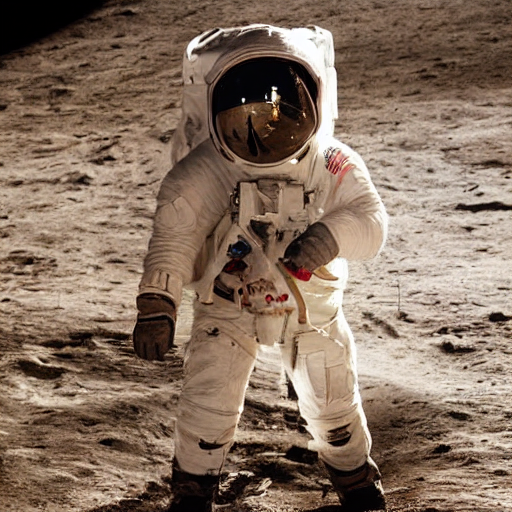

In [18]:
TARGET_NEGATIVE_PROMPT = (
    "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"
)

def generate_advanced_image(
    prompt: str,
    negative_prompt: str = "",
    seed: int = 42,
    guidance_scale: float = 7.5,
    num_inference_step: int = 50,
    width: int = 512,
    height: int = 512,
):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=float(guidance_scale),
        num_inference_steps=int(num_inference_step),
        width=width,
        height=height,
    )
    return result.images[0]


advanced_image = generate_advanced_image(
    prompt=TARGET_PROMPT,
    negative_prompt=TARGET_NEGATIVE_PROMPT,
    seed=TARGET_SEED,
    guidance_scale=2.0,
    num_inference_step=50,
)
display(advanced_image)

## **Guidance Scale Comparison**

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
*"Gambar terlihat lebih bebas dan sedikit kurang ketat mengikuti prompt. Detail masih cukup jelas, tetapi ada variasi visual yang lebih besar, sehingga hasilnya terasa lebih natural dan sedikit lebih kreatif. Pada contoh ini, astronaut dan lanskap Mars tetap muncul, namun komposisi dan nuansa gambar terasa lebih longgar."*

*   **Gambar dengan "Scale" Tinggi:**   
*"Sangat mengikuti prompt namun menghasilkan output yang hampir tidak ada bedanya dengan generate image tanpa hyperparameter, hanya ditambahkan beberapa detail kecil yang tidak terlalu signifikan."*

## **Inference Steps Comparison**

### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
*"Gambar cenderung lebih sederhana dan detailnya belum sepenuhnya matang. Ketajaman bisa lebih rendah, dan ada kemungkinan terlihat noise, tekstur kasar, atau bentuk yang belum terlalu stabil. Hasilnya biasanya masih cukup menggambarkan prompt, tetapi elemen visualnya belum sepenuhnya halus."*
*   **Gambar dengan "Step" Tinggi:**  
*"Gambar terlihat lebih detail, lebih halus, dan lebih stabil secara visual. Objek utama menjadi lebih tegas, komposisi lebih rapi, dan noise atau artefak cenderung berkurang. Dibandingkan step rendah, hasilnya biasanya memberi kesan lebih selesai dan lebih nyaman dilihat."*

## **Batch Inference from One Prompt**

## **Load Scheduler**

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DPM++ Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DDIM Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Base + Refiner Image Generation**

## **Inpainting**

### **Load Model Inpainting**

In [5]:
import gc
from diffusers import StableDiffusionInpaintPipeline, DPMSolverMultistepScheduler

INPAINT_MODEL_ID = "runwayml/stable-diffusion-inpainting"

# Free base text2img pipeline from GPU before loading inpaint model
if "pipe" in globals():
    try:
        pipe.to("cpu")
    except Exception:
        pass
    del pipe
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    INPAINT_MODEL_ID,
    torch_dtype=DTYPE,
 )
inpaint_pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    inpaint_pipe.scheduler.config,
 )
inpaint_pipe = inpaint_pipe.to(DEVICE)

if DEVICE == "cuda":
    inpaint_pipe.enable_attention_slicing()

def inpaint_engine(
    image,
    mask,
    prompt,
    negative_prompt="",
    seed=42,
    guidance_scale=7.5,
    num_inference_steps=35,
    strength=0.99,
 ):
    image = image.convert("RGB")
    mask = mask.convert("L")  # single-channel mask: white=repaint, black=keep
    if image.size != mask.size:
        raise ValueError(f"image/mask size mismatch: {image.size} vs {mask.size}")

    generator = torch.Generator(
        device=("cuda" if DEVICE == "cuda" else "cpu")
    ).manual_seed(int(seed))

    result = inpaint_pipe(
        prompt=prompt,
        image=image,
        mask_image=mask,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=float(guidance_scale),
        num_inference_steps=int(num_inference_steps),
        strength=float(strength),
    )
    return result.images[0]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to rais

### **Manual Masking**

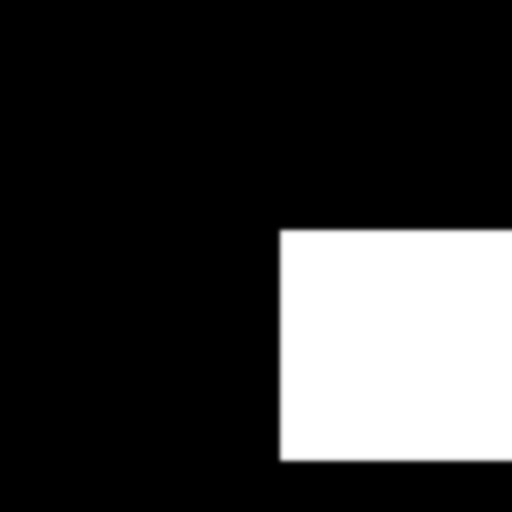

In [10]:
from PIL import Image, ImageDraw, ImageFilter

# simple_image is 512x512; white = repaint, black = keep.
# The mask is intentionally larger so the model has enough room to draw a full satellite.
w, h = simple_image.size  # 512x512

# L mode mask: 0=keep, 255=repaint
mask = Image.new("L", (w, h), 0)
draw = ImageDraw.Draw(mask)

# Main paint region on the right side of astronaut (satellite body + nearby ground)
draw.rectangle([280, 230, 511, 460], fill=255)

# Slightly blur mask edges to blend with surrounding pixels and avoid hard seams
mask = mask.filter(ImageFilter.GaussianBlur(radius=2))

display(mask)

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

Average pixel difference vs original: 15.84


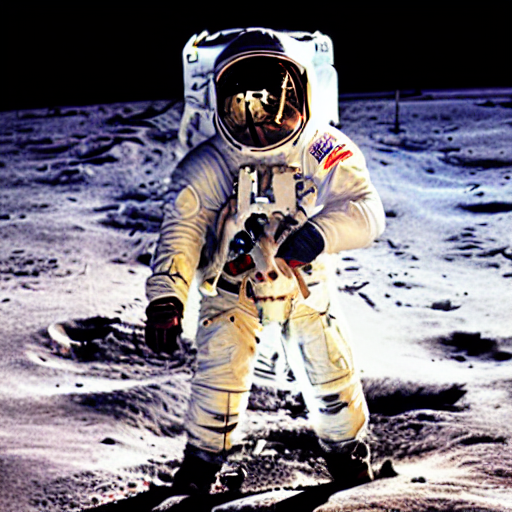

In [19]:
INPAINT_PROMPT = (
    "A broken cartoon satellite on red Martian soil beside the astronaut, "
    "with bent solar panels, a damaged metallic body, scattered debris, "
    "simple clean line art, cute whimsical sci-fi illustration, soft warm lighting, "
    "high contrast, vivid colors, no text, no watermark."
)
INPAINT_NEGATIVE_PROMPT = (
    "photorealistic, realistic, 3D render, blurry, low quality, worst quality, "
    "cropped, distorted, messy, extra parts, extra limbs, text, watermark, signature"
)

inpainted_image = inpaint_engine(
    image=simple_image,
    mask=mask,
    prompt=INPAINT_PROMPT,
    negative_prompt=INPAINT_NEGATIVE_PROMPT,
    seed=9,
    guidance_scale=2.0,
    num_inference_steps=50,
    strength=1.0,
)

# Quick verification that output is not identical to input
import numpy as np
pixel_diff = np.mean(np.abs(np.array(inpainted_image, dtype=np.float32) - np.array(simple_image, dtype=np.float32)))
print(f"Average pixel difference vs original: {pixel_diff:.2f}")

display(inpainted_image)

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

### **Masking with Segmentation Model**

### **Generate**

## **Outpainting**

### **Prepare the Canvas**

### **Generate**

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

### **Generate**